I0000 00:00:1701023504.231463   93085 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-11-26 19:31:49.398475: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
W0000 00:00:1701023527.584944   93085 graph_launch.cc:158] Evict all gpu graphs from executor 0x7f44bc001340
W0000 00:00:1701023527.587444   93085 graph_launch.cc:356] InstantiateAllGraph failed due to insufficient memory. Uninitializd graphs will run in op-by-op mode.
W0000 00:00:1701023528.162884   93085 graph_launch.cc:158] Evict all gpu graphs from executor 0x7f44bc001340
W0000 00:00:1701023528.163932   93085 graph_launch.cc:356] InstantiateAllGraph failed due to insufficient memory. Uninitializd gr

XlaRuntimeError: INTERNAL: Failed to execute XLA Runtime executable: run time error: custom call 'xla.gpu.custom_call' failed: jaxlib/gpu/blas_kernels.cc:44: operation gpublasCreate(&handle) failed: cuBlas allocation failure; current tracing scope: custom-call.0; current profiling annotation: XlaModule:#hlo_module=jit_expm,program_id=159#.

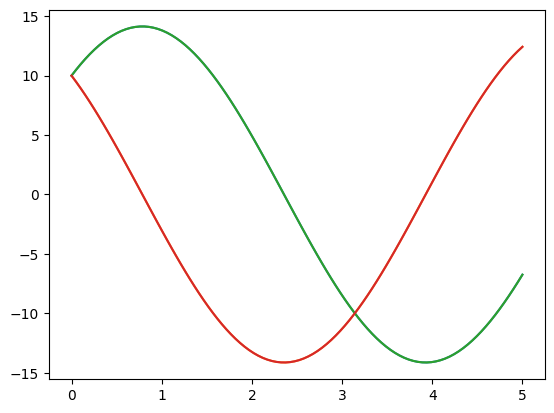

In [1]:
import jax
import jax.numpy as jnp

from probjax.utils.odeint import _odeint as odeint

A = jnp.array([[0., 1.], [-1., -0.]])
# Define the ODE
def f(t, x):
    return jnp.dot(A, x) 

def true_f(t):
    Phi = jax.scipy.linalg.expm(A * t)
    return Phi@x0

# Define the initial condition
x0 = jnp.ones((2,))*10

# Define the time points to evaluate
t = jnp.linspace(0., 5, 100)

# Solve the ODE
x = odeint(f, x0, t, method="exp_euler")

# Solve the ODE with dt
#with jax.disable_jit():
x2 = odeint(f, x0, t, method="dopri5", atol=1e-8, rtol=1e-8)

# Plot the solution
import matplotlib.pyplot as plt
plt.plot(t, x)
plt.plot(t, x2)
plt.plot(t, jax.vmap(true_f)(t), color="black")
plt.show()
plt.plot(t, jnp.abs(x - jax.vmap(true_f)(t)).sum(axis=-1), alpha=0.5)
plt.plot(t, jnp.abs(x2 - jax.vmap(true_f)(t)).sum(axis=-1), alpha=0.5)